In [35]:
from rdkit.Chem import AllChem as Chem
from rdkit.Chem.Scaffolds.MurckoScaffold import MurckoScaffoldSmiles
from rdkit.Chem.Draw import MolsMatrixToGridImage
from rdkit.Chem import Descriptors
from rdkit.Chem.Draw import MolsToGridImage

import pandas as pd
from collections import defaultdict

In [4]:
esol_filepath = r"../data/raw/esol.csv"
esol_df = pd.read_csv(esol_filepath)
esol_df.head()

,SMILES,label
0,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,-0.77
1,Cc1occc1C(=O)Nc2ccccc2,-3.30
2,CC(C)=CCCC(C)=CC(=O),-2.06
3,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43,-7.87
4,c1ccsc1,-1.33


In [10]:
scaffolds2mols = defaultdict(list)
for smiles in esol_df["SMILES"]:
    scaffolds2mols[MurckoScaffoldSmiles(smiles)].append(smiles)

for scaffold, mols in scaffolds2mols.items():
    print(f'{scaffold=} {len(mols)}')

scaffold='c1ccc(COC2CCCC(COC3CCCCO3)O2)cc1' 1
scaffold='O=C(Nc1ccccc1)c1ccoc1' 1
scaffold='' 317
scaffold='c1ccc2c(c1)ccc1c2ccc2c3ccccc3ccc21' 1
scaffold='c1ccsc1' 1
scaffold='c1ccc2scnc2c1' 3
scaffold='c1ccc(-c2ccccc2)cc1' 39
scaffold='c1ccc2c(c1)CCC1C2CCC2CCCC21' 3
scaffold='C1=CC2CC1C1C3CC(C4OC34)C21' 1
scaffold='O=C1c2ccc3c(c2OC2COc4ccccc4C12)CCO3' 1
scaffold='O=C1CCCN1' 1
scaffold='c1ccc2ccccc2c1' 22
scaffold='O=C1NCNC(=O)C1c1ccccc1' 1
scaffold='c1ccccc1' 254
scaffold='c1cncnc1' 5
scaffold='O=c1[nH]c2c(c(=O)n1C1CCCCC1)CCC2' 1
scaffold='O=c1[nH]c(=O)c2[nH]cnc2[nH]1' 4
scaffold='O=C1CC(=O)NC(=O)N1' 21
scaffold='C=C(c1ccccc1)c1ccccc1' 1
scaffold='O=C(Nc1ccccc1)Oc1ccccc1' 2
scaffold='c1ccc2c(c1)Cc1ccccc1-2' 2
scaffold='c1ccc(Nc2ccccc2)cc1' 1
scaffold='C1CCNCC1' 1
scaffold='O=C1NC(=O)C2(CCC2)C(=O)N1' 1
scaffold='C1CCCCC1' 10
scaffold='O=c1cccnn1-c1ccccc1' 3
scaffold='C1=CC(c2ccccc2)C=CN1' 1
scaffold='c1ccc2ncccc2c1' 5
scaffold='O=C1NC(=O)C(C2=CCCCC2)C(=O)N1' 1
scaffold='c1ccc2c(c1)ccc1

/home/ilya/Documents/projects/bioinformatics-ml/.venv/lib/python3.12/site-packages/rdkit/Chem/Draw/IPythonConsole.py:376: UserWarning: Truncating the list of molecules to be displayed to 50. Change the maxMols value to display more.
  warnings.warn(


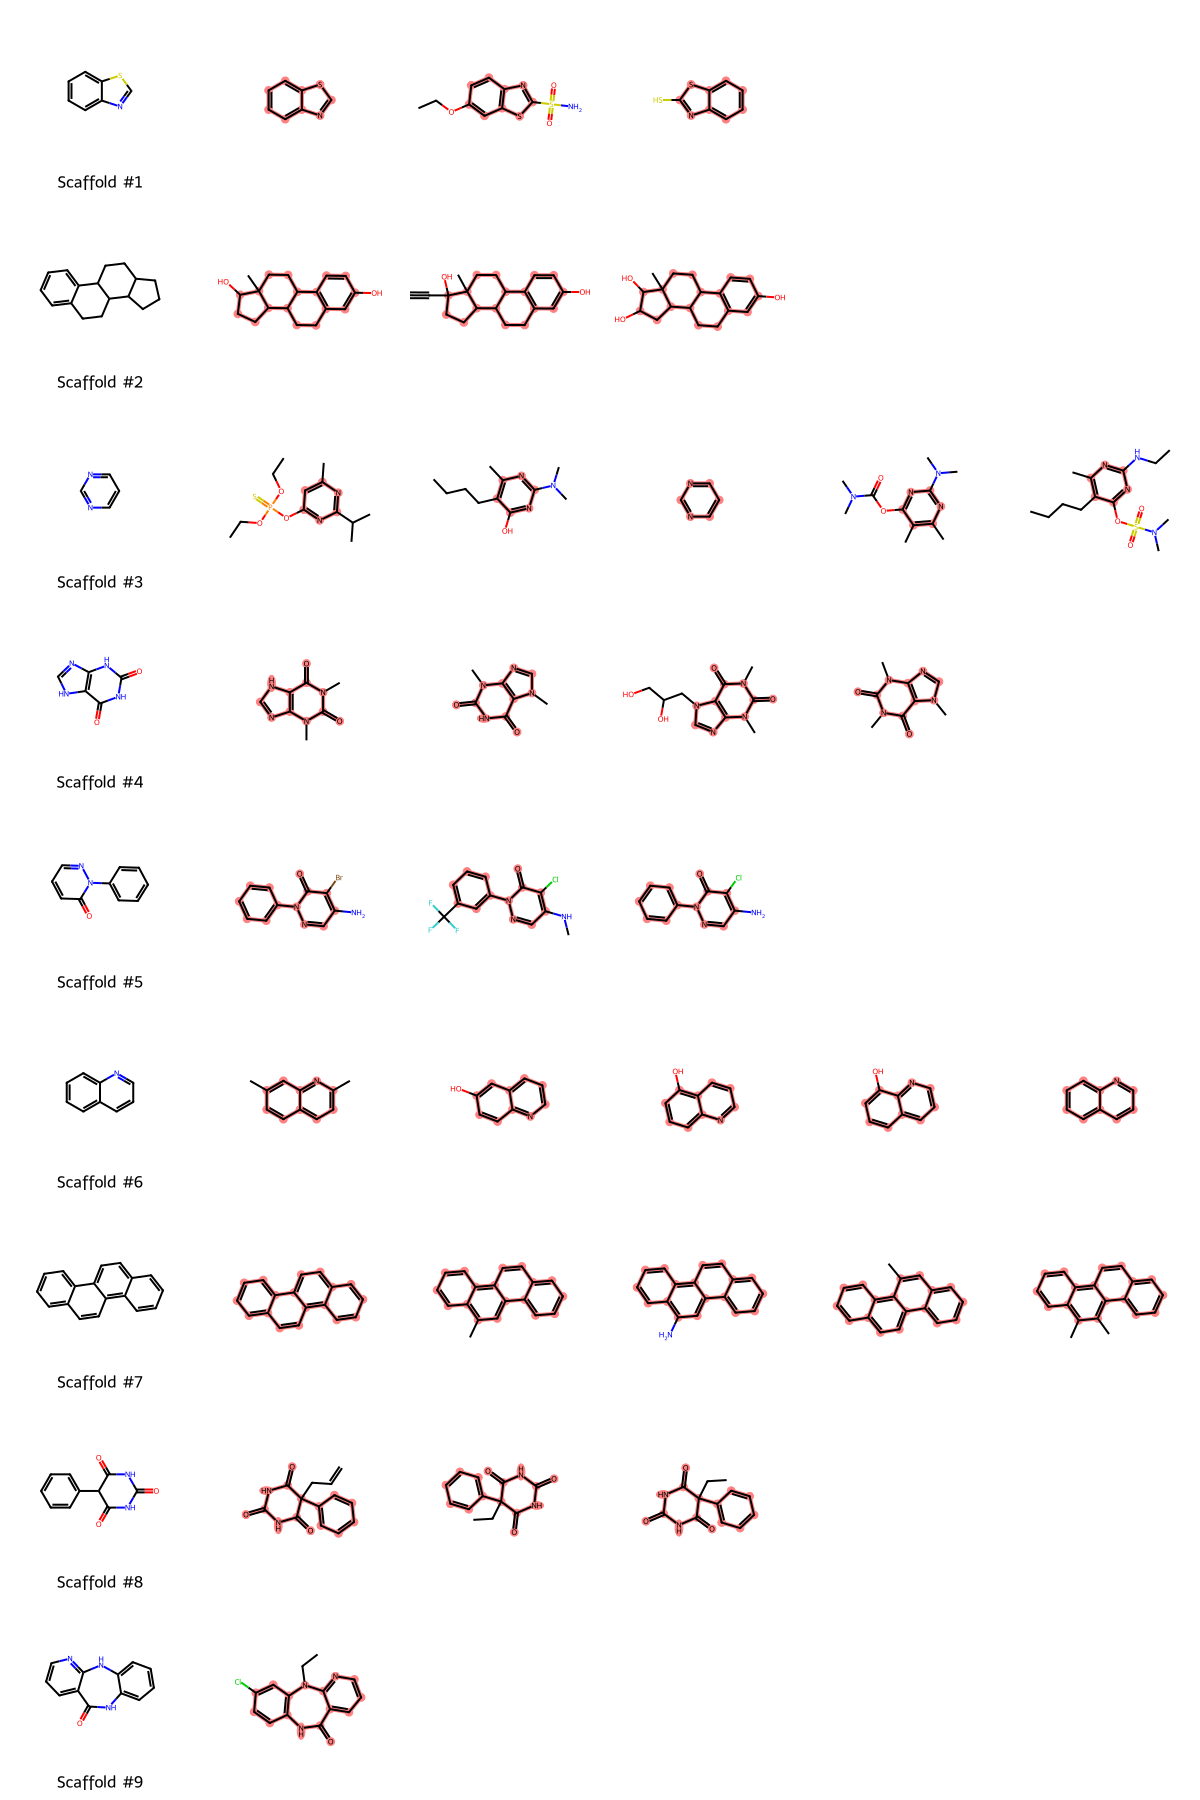

In [28]:
# Pick scaffolds with the number of molecules [3, 5] for convenient plots
example_scaffolds = {
    k:v 
    for k, v in scaffolds2mols.items() 
    if 3 <= len(v) <= 5
}

# The next 3 groups are the arguments for MolsMatrixToGridImage

# molsMatrix
molsMatrix = []
for scaffold, mols in example_scaffolds.items():
    molsMatrix.append(
        [Chem.MolFromSmiles(scaffold)] 
        + [Chem.MolFromSmiles(mol) for mol in mols]
    )

# legendsMatrix
legendsMatrix = []
for idx, row in enumerate(molsMatrix, start=1):
    n_examples = len(row) - 1
    labels_row = [f"Scaffold #{idx}"] + [""] * n_examples
    legendsMatrix.append(labels_row)

# highlightAtomListMatrix
highlightAtomListMatrix = []
for row in molsMatrix:
    scaffold_mol = row[0]
    rest_mols = row[1:]
    
    # Highlight scaffolds in all molecule except for scaffold itself (the first molecule)
    highlight_row = [()] + [mol.GetSubstructMatch(scaffold_mol) for mol in rest_mols]
    highlightAtomListMatrix.append(highlight_row)

# Draw grid image
MolsMatrixToGridImage(
    molsMatrix=molsMatrix,
    legendsMatrix=legendsMatrix,
    highlightAtomListsMatrix=highlightAtomListMatrix
)

In [25]:
def scaffold_splits(
    smiles_list: list[str], 
    frac_train: float = 0.8, 
    frac_val: float = 0.1, 
    frac_test: float = 0.1
) -> tuple[list[int], list[int], list[int]]:
    assert frac_train + frac_test + frac_val == 1, "Train / Val / Test fractions do not sum up to 1!"

    scaffold_indices = defaultdict(list)
    for idx, smiles in enumerate(smiles_list):
        scaffold_indices[MurckoScaffoldSmiles(smiles=smiles)].append(idx)

    train_idx, val_idx, test_idx = [], [], []
    for indices in sorted(scaffold_indices.values(), key=len, reverse=True):
        if len(train_idx) + len(indices) <= frac_train * len(smiles_list):
            train_idx += indices
        elif len(val_idx) + len(indices) <= frac_val * len(smiles_list):
            val_idx += indices
        else:
            test_idx += indices

    return train_idx, val_idx, test_idx

In [26]:
smiles_list = esol_df["SMILES"]
train_idx, val_idx, test_idx = scaffold_splits(smiles_list)
print(f'Train: {len(train_idx)/len(smiles_list)}')
print(f'Val: {len(val_idx) / len(smiles_list)}')
print(f'Test: {len(test_idx) / len(smiles_list)}')

Train: 0.799645390070922
Val: 0.09929078014184398
Test: 0.10106382978723404
